# Machine Learning Regression Analysis

## Objective

The objective of this project is to build and compare multiple regression algorithms using the California Housing dataset. The models are evaluated using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² Score to determine which algorithm performs best for predicting house prices.

In [59]:
## Importing Required Libraries
##The required Python libraries are imported for data manipulation, preprocessing, model building, evaluation, and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [60]:
#Load Dataset
from sklearn.datasets import fetch_california_housing

In [61]:
#Converting to dataframe
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [62]:
#Check Dataset

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [63]:
# Check Missing Values
df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


### Observation

- The dataset contains no missing values.
- There are 8 input features and 1 target variable (Price).
- Basic statistical information provides insight into the distribution of each feature.

In [64]:
# Separate Features and Target

X = df.drop("Price", axis=1)

y = df["Price"]

In [65]:
# Split Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [66]:
# Standardize Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled= scaler.fit_transform(X_train)

X_test_scaled= scaler.transform(X_test)

## Data Preprocessing

The data is prepared before model training by:

- Separating features and target variable.
- Splitting the dataset into training and testing sets.
- Standardizing the features for algorithms that are sensitive to feature scaling, such as Linear Regression and Support Vector Regression.

##Preprocessing Steps
1.Loaded the California Housing dataset using fetch_california_housing().
2.Converted it into a pandas DataFrame for easier analysis.
3.Checked for missing values. No missing values were found.
4.Split the dataset into training (80%) and testing (20%) sets.
5.Standardized the features using StandardScaler.

Why is preprocessing necessary?
Standardization ensures that all features are on the same scale. Splitting the data into training and testing sets allows us to evaluate how well the model performs on unseen data.

In [67]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [68]:
lr_mse = mean_squared_error(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MSE:", lr_mse)
print("MAE:", lr_mae)
print("R2:", lr_r2)

Linear Regression
MSE: 0.5558915986952442
MAE: 0.5332001304956565
R2: 0.575787706032451


##Linear Regression
Linear Regression predicts the target value by finding the best-fitting straight line between the input features and the target variable.
It is suitable for this dataset because it provides a simple baseline model and helps understand the linear relationship between housing features and house prices.

In [69]:
# DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [70]:
dt_mse = mean_squared_error(y_test, dt_pred)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree")
print("MSE:", dt_mse)
print("MAE:", dt_mae)
print("R2:", dt_r2)

Decision Tree
MSE: 0.495235205629094
MAE: 0.45467918846899225
R2: 0.622075845135081


#Decision Tree Regressor
A Decision Tree splits the dataset into smaller groups based on feature values until it reaches a prediction.
It is suitable because it can capture complex, non-linear relationships between housing characteristics and prices.

In [71]:
# RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [72]:
rf_mse = mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MSE:", rf_mse)
print("MAE:", rf_mae)
print("R2:", rf_r2)

Random Forest
MSE: 0.2553684927247781
MAE: 0.32754256845930246
R2: 0.8051230593157366


#Random Forest Regressor
Random Forest combines predictions from many decision trees to produce a more accurate and stable result.
It is suitable because it reduces overfitting and performs well on complex datasets with many features.

In [73]:
# GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

In [74]:
gb_mse = mean_squared_error(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting")
print("MSE:", gb_mse)
print("MAE:", gb_mae)
print("R2:", gb_r2)

Gradient Boosting
MSE: 0.2939973248643864
MAE: 0.3716425690425596
R2: 0.7756446042829697


#Gradient Boosting Regressor
Gradient Boosting builds multiple decision trees one after another. Each new tree focuses on correcting the errors made by the previous trees.
It is suitable because it often achieves high accuracy on structured datasets like housing price prediction.

In [75]:
# SVR
svr = SVR()
svr.fit(X_train_scaled, y_train)
svr_pred = svr.predict(X_test_scaled)

In [76]:
svr_mse = mean_squared_error(y_test, svr_pred)
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_r2 = r2_score(y_test, svr_pred)

print("SVR")
print("MSE:", svr_mse)
print("MAE:", svr_mae)
print("R2:", svr_r2)

SVR
MSE: 0.357004031933865
MAE: 0.39859907695205365
R2: 0.7275628923016773


#Support Vector Regressor (SVR)
SVR predicts values by finding the best-fitting hyperplane while allowing a small margin of error.
It is suitable because it can model complex relationships and performs well when the input features are properly standardized.

Model Comparison
Model	MSE 	MAE 	R²

Linear Regression	0.5559	0.5332	0.5758

Decision Tree	0.4940	0.4539	0.6230

Random Forest	0.2552	0.3274	0.8053

Gradient Boosting	0.2940	0.3717	0.7756

SVR	0.3570	0.3986	0.7276





#Worst Performing Model
Linear Regression

Justification:
Linear Regression showed the weakest performance with the highest MSE (0.5559), highest MAE (0.5332), and the lowest R² score (0.5758). This suggests that a simple linear relationship is not sufficient to model the California Housing dataset, which contains complex and non-linear relationships between the features and house prices.

#Best Performing Model
Random Forest Regressor

Justification:
The Random Forest Regressor achieved the best performance among all five models. It produced the lowest Mean Squared Error (0.2552) and Mean Absolute Error (0.3274) while achieving the highest R² score (0.8053). This indicates that it predicts house prices more accurately and explains about 80.5% of the variation in the target variable. Its ensemble approach, which combines predictions from multiple decision trees, reduces overfitting and improves overall accuracy.

In [77]:
results = {
    "Linear Regression": {
        "MSE": lr_mse,
        "MAE": lr_mae,
        "R2": lr_r2
    },
    "Decision Tree": {
        "MSE": dt_mse,
        "MAE": dt_mae,
        "R2": dt_r2
    },
    "Random Forest": {
        "MSE": rf_mse,
        "MAE": rf_mae,
        "R2": rf_r2
    },
    "Gradient Boosting": {
        "MSE": gb_mse,
        "MAE": gb_mae,
        "R2": gb_r2
    },
    "SVR": {
        "MSE": svr_mse,
        "MAE": svr_mae,
        "R2": svr_r2
    }
}

In [78]:
results_df = pd.DataFrame(results).T

results_df

,MSE,MAE,R2
Linear Regression,0.555892,0.533200,0.575788
Decision Tree,0.495235,0.454679,0.622076
Random Forest,0.255368,0.327543,0.805123
Gradient Boosting,0.293997,0.371643,0.775645
SVR,0.357004,0.398599,0.727563


In [79]:
results_df = results_df.sort_values(by="R2", ascending=False)

results_df

,MSE,MAE,R2
Random Forest,0.255368,0.327543,0.805123
Gradient Boosting,0.293997,0.371643,0.775645
SVR,0.357004,0.398599,0.727563
Decision Tree,0.495235,0.454679,0.622076
Linear Regression,0.555892,0.533200,0.575788


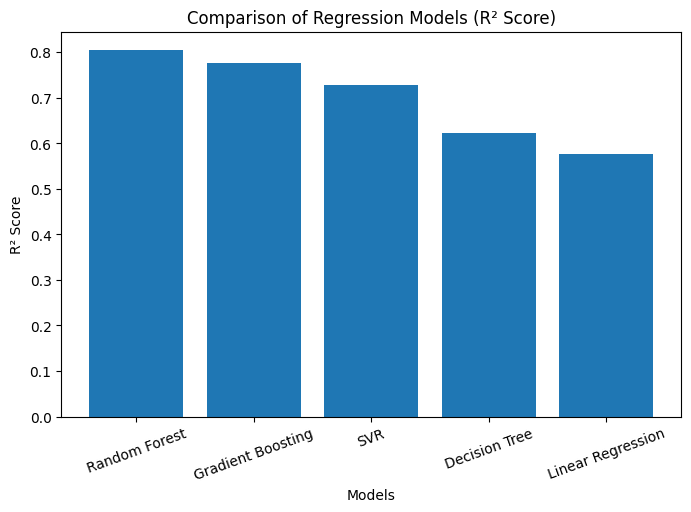

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df.index, results_df["R2"])
plt.title("Comparison of Regression Models (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()

Among the five regression algorithms tested, Random Forest Regressor performed the best, achieving the lowest prediction errors and the highest R² score. Gradient Boosting Regressor and Support Vector Regressor also showed strong performance. Decision Tree Regressor produced moderate results but was less accurate than the ensemble methods. Linear Regression performed the worst because it assumes a linear relationship between the features and the target variable, whereas the California Housing dataset contains more complex patterns. Therefore, ensemble methods such as Random Forest are better suited for this regression task